# MOMARL Results Visualization

Visualize Multi-Objective Multi-Agent RL training results from WandB logs.

**Features:** Pareto front, hypervolume comparison, hypervolume learning curve

## 1. Configuration

In [1]:
from pathlib import Path

# Paths
RESULTS_DIR = Path("../../momarl_results/welfare_experiments_2")
OUTPUT_DIR = Path("./figures")

# Hypervolume reference point (origin for maximization)
HYPERVOLUME_REF_POINT = [0.0, 0.0]

# Objective names for axis labels
# objectives are: "global_economic_output", "welfare", "temperature_threshold", "inverse_global_temperature"
OBJECTIVE_NAMES = ["inverse_global_temperature", "global_economic_output"]

# Plot settings
ALGORITHM_COMPARISON = True  # Set to False to plot only one algorithm
COLORS = {"HAPPO": "#133eb6", "MAPPO": "#ff0e76", "UNKNOWN": "#ffb6c1"}
FIGURE_DPI = 150
SAVE_FIGURES = True

# Filter runs with returns below these thresholds (set to None to disable)
MIN_RETURN_OBJ_0 = 0.0
MIN_RETURN_OBJ_1 = 0.0

# WandB settings
USE_WANDB_API = True
WANDB_PROJECT = "momarl_happo_mappo"
WANDB_ENTITY = "olaandrasz-tu-delft"

## 2. Imports

In [108]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
import warnings

# Hypervolume (DEAP)
try:
    from deap.tools._hypervolume import hv
    HV_AVAILABLE = True
except ImportError:
    HV_AVAILABLE = False
    warnings.warn("DEAP not installed - hypervolume unavailable")

# WandB
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False
    warnings.warn("wandb not installed")

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"HV: {HV_AVAILABLE}, WandB: {WANDB_AVAILABLE}")

if WANDB_AVAILABLE and USE_WANDB_API:
    try:
        wandb.login()
        print("WandB login successful")
    except Exception as e:
        print(f"WandB login failed: {e}")

HV: True, WandB: True
WandB login successful


## 3. Data Loading

In [ ]:
@dataclass
class RunData:
    """Container for a single WandB run."""
    run_id: str
    algorithm: str
    weights: List[float]
    weight_idx: int
    rewards: List[str]
    return_obj_0: float
    return_obj_1: float
    vector_return: List[float]
    timestamp: str
    total_steps: int


def load_json(path: Path) -> Optional[Dict]:
    if not path.exists():
        return None
    with open(path, 'r') as f:
        return json.load(f)

def load_yaml(path: Path) -> Optional[Dict]:
    if not path.exists():
        return None
    import yaml
    with open(path, 'r') as f:
        return yaml.safe_load(f)

def extract_algorithm(metadata: Dict) -> str:
    """Extract algorithm name from wandb metadata args."""
    args = metadata.get("args", [])
    for i, arg in enumerate(args):
        if arg == "--algo" and i + 1 < len(args):
            return args[i + 1].upper()
    return "UNKNOWN"


def parse_run(run_dir: Path) -> Optional[RunData]:
    """Parse a single WandB run directory."""
    metadata = load_json(run_dir / "files" / "wandb-metadata.json")
    summary = load_json(run_dir / "files" / "wandb-summary.json")
    config = load_yaml(run_dir / "files" / "config.yaml")
    
    
    if metadata is None or summary is None:
        return None
    
    run_name = run_dir.name
    parts = run_name.split("-")
    #print(config.get("rewards", {}).get("value", []), run_name)
    
    return RunData(
        run_id=parts[-1] if len(parts) > 1 else run_name,
        algorithm=config.get("algorithm", {}).get("value", "UNKNOWN").upper(),
        weights=summary.get("weights", [0.5, 0.5]),
        weight_idx=summary.get("weight_idx", -1),
        rewards=config.get("rewards", dict()).get("value", []),
        return_obj_0=summary.get("return_obj_0") or summary.get("final/return_obj_0") or 0.0,
        return_obj_1=summary.get("return_obj_1") or summary.get("final/return_obj_1") or 0.0,
        vector_return=summary.get("vector_return") or summary.get("final/vector_return") or [0.0, 0.0],
        timestamp=parts[1] if len(parts) > 1 else "",
        total_steps=summary.get("total_num_steps", 0)
    )


def load_all_runs(results_dir: Path) -> List[RunData]:
    """Load all WandB runs from a directory."""
    run_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir() and d.name.startswith("run-")])
    runs = [parse_run(d) for d in run_dirs]
    return [r for r in runs if r is not None]


def runs_to_dataframe(runs: List[RunData]) -> pd.DataFrame:
    """Convert RunData list to DataFrame."""
    return pd.DataFrame([{
        "run_id": r.run_id,
        "algorithm": r.algorithm,
        "weight_0": r.weights[0] if r.weights else 0.0,
        "weight_1": r.weights[1] if len(r.weights) > 1 else 0.0,
        "weight_idx": r.weight_idx,
        "reward_0": r.rewards[0] if len(r.rewards) > 0 else "",
        "reward_1": r.rewards[1] if len(r.rewards) > 1 else "",
        "return_obj_0": r.return_obj_0,
        "return_obj_1": r.return_obj_1,
        "timestamp": r.timestamp,
        "total_steps": r.total_steps,
    } for r in runs])

## 4. Load Runs

In [110]:
runs = load_all_runs(RESULTS_DIR)
df = runs_to_dataframe(runs)


print(f"Loaded {len(df)} runs from {RESULTS_DIR}")
print(df["algorithm"].value_counts())
print(df["reward_0"].value_counts())
print(df["reward_1"].value_counts())

# Filter based on OBJECTIVE_0 and OBJECTIVE_1 names
if OBJECTIVE_NAMES[0] and OBJECTIVE_NAMES[1]:
    df = df[
        (df["reward_0"] == OBJECTIVE_NAMES[0]) &
        (df["reward_1"] == OBJECTIVE_NAMES[1])
    ]
    
print(f"\nAfter filtering by reward names: {len(df)} runs")
print(df["reward_0"].value_counts())
print(df["reward_1"].value_counts())
df.head(10)

Loaded 230 runs from ../../momarl_results/welfare_experiments_2
algorithm
UNKNOWN    230
Name: count, dtype: int64
reward_0
temperature_threshold     100
global_economic_output    100
                           30
Name: count, dtype: int64
reward_1
welfare    200
            30
Name: count, dtype: int64

After filtering by reward names: 100 runs
reward_0
global_economic_output    100
Name: count, dtype: int64
reward_1
welfare    100
Name: count, dtype: int64


,run_id,algorithm,weight_0,weight_1,weight_idx,reward_0,reward_1,return_obj_0,return_obj_1,timestamp,total_steps
110,qzzd8jai,UNKNOWN,0.000000,1.000000,0,global_economic_output,welfare,201.305462,-113.464608,20260326_040336,2508000
111,57ui8wor,UNKNOWN,0.050067,0.949933,0,global_economic_output,welfare,203.101546,-113.428405,20260326_041300,2508000
112,yu7tp49v,UNKNOWN,0.150527,0.849473,0,global_economic_output,welfare,215.433912,-113.118069,20260326_041300,2508000
113,irp6bo7k,UNKNOWN,0.100278,0.899722,0,global_economic_output,welfare,206.091518,-113.305557,20260326_041301,2508000
114,axt5r225,UNKNOWN,0.352273,0.647727,0,global_economic_output,welfare,220.482780,-113.301304,20260326_042435,2508000
115,eq8lmnhu,UNKNOWN,0.402745,0.597255,0,global_economic_output,welfare,228.194215,-113.558657,20260326_042435,2508000
116,n08ukoah,UNKNOWN,0.453308,0.546692,0,global_economic_output,welfare,232.560441,-113.629571,20260326_042435,2508000
117,pzea9fir,UNKNOWN,0.251196,0.748804,0,global_economic_output,welfare,218.462272,-113.422275,20260326_042435,2508000
118,vgs5ihpr,UNKNOWN,0.301663,0.698337,0,global_economic_output,welfare,215.153897,-113.275962,20260326_042435,2508000
119,ymqxg8ip,UNKNOWN,0.200736,0.799264,0,global_economic_output,welfare,212.310173,-113.503000,20260326_042435,2508000


## 5. Pareto Front

In [111]:
MARKERS = {"HAPPO": "o", "MAPPO": "s", "UNKNOWN": "o"}

# Plotly markers (different naming)
PLOTLY_MARKERS = {"HAPPO": "circle", "MAPPO": "square", "UNKNOWN": "circle"}

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not installed - interactive plots unavailable")


def is_pareto_efficient(points: np.ndarray) -> np.ndarray:
    """Return boolean mask of Pareto-efficient points (maximization)."""
    n = len(points)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and np.all(points[j] >= points[i]) and np.any(points[j] > points[i]):
                is_efficient[i] = False
                break
    return is_efficient


def plot_pareto_front_interactive(df: pd.DataFrame) -> go.Figure:
    """Plot interactive Pareto front with hover info (weight, run_id).
    Includes checkbox to show/hide dominated (non-Pareto) points."""
    fig = go.Figure()
    
    algos = list(df["algorithm"].unique())
    if not ALGORITHM_COMPARISON and len(algos) > 1:
        # When only a single algorithm should be shown, select the most frequent one
        algos = [df["algorithm"].value_counts().idxmax()]
    
    dominated_trace_indices = []  # Track indices of dominated point traces
    trace_idx = 0
    
    for algo in algos:
        algo_df = df[df["algorithm"] == algo].reset_index(drop=True)
        points = algo_df[["return_obj_0", "return_obj_1"]].values
        color = COLORS.get(algo, "#333")
        marker = PLOTLY_MARKERS.get(algo, "circle")
        
        pareto_mask = is_pareto_efficient(points) if len(points) > 0 else np.zeros(len(points), dtype=bool)
        non_pareto_mask = ~pareto_mask
        
        # Create hover text with weight and run_id
        hover_text = [
            f"Run: {row['run_id']}<br>Weight: ({row['weight_0']:.2f}, {row['weight_1']:.2f})<br>"
            f"{OBJECTIVE_NAMES[0]}: {row['return_obj_0']:.2f}<br>{OBJECTIVE_NAMES[1]}: {row['return_obj_1']:.2f}"
            for _, row in algo_df.iterrows()
        ]
        
        # Add dominated (non-Pareto) points first (faded, hidden by default)
        if non_pareto_mask.any():
            non_pareto_df = algo_df[non_pareto_mask]
            non_pareto_hover = [hover_text[i] for i in range(len(algo_df)) if non_pareto_mask[i]]
            fig.add_trace(go.Scatter(
                x=non_pareto_df["return_obj_0"],
                y=non_pareto_df["return_obj_1"],
                mode="markers",
                marker=dict(size=10, color=color, symbol=marker, opacity=0.4,
                           line=dict(width=1, color="gray")),
                name=f"{algo} (dominated)",
                hovertemplate="%{customdata}<extra></extra>",
                customdata=non_pareto_hover,
                visible=False  # Hidden by default
            ))
            dominated_trace_indices.append(trace_idx)
            trace_idx += 1
        
        # Add Pareto points (highlighted)
        if pareto_mask.any():
            pareto_df = algo_df[pareto_mask]
            pareto_hover = [hover_text[i] for i in range(len(algo_df)) if pareto_mask[i]]
            fig.add_trace(go.Scatter(
                x=pareto_df["return_obj_0"],
                y=pareto_df["return_obj_1"],
                mode="markers",
                marker=dict(size=14, color=color, symbol=marker, 
                           line=dict(width=2, color="gray")),
                name=f"{algo} (Pareto)",
                hovertemplate="%{customdata}<extra></extra>",
                customdata=pareto_hover
            ))
            trace_idx += 1
    
    # Create visibility arrays for toggle buttons
    n_traces = len(fig.data)
    # Pareto only: dominated traces hidden
    pareto_only_visible = [True] * n_traces
    for i in dominated_trace_indices:
        pareto_only_visible[i] = False
    
    # All points: everything visible
    all_visible = [True] * n_traces
    
    title_text = "Pareto Front"
    if ALGORITHM_COMPARISON:
        title_text += ": HAPPO vs MAPPO"
    
    fig.update_layout(
        title=dict(text=title_text, font=dict(size=16, weight="bold")),
        xaxis_title=OBJECTIVE_NAMES[0].replace('_', ' ').title(),
        yaxis_title=OBJECTIVE_NAMES[1].replace('_', ' ').title(),
        legend=dict(x=0.98, y=0.98, xanchor="right", yanchor="bottom"),
        hovermode="closest",
        width=900,
        height=650,
        # Add toggle buttons
        updatemenus=[
            dict(
                type="buttons",
                direction="left",
                buttons=[
                    dict(
                        args=[{"visible": pareto_only_visible}],
                        label="Pareto Only",
                        method="update"
                    ),
                    dict(
                        args=[{"visible": all_visible}],
                        label="Show All Points",
                        method="update"
                    ),
                ],
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0.0,
                xanchor="left",
                y=1.12,
                yanchor="top"
            ),
        ],
    )
    
    return fig


def plot_pareto_front(df: pd.DataFrame, show_weights: bool = True) -> plt.Figure:
    """Plot Pareto front comparison between algorithms (static matplotlib)."""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    algos = list(df["algorithm"].unique())
    if not ALGORITHM_COMPARISON and len(algos) > 1:
        # When only a single algorithm should be shown, select the most frequent one
        algos = [df["algorithm"].value_counts().idxmax()]
    
    for algo in algos:
        algo_df = df[df["algorithm"] == algo]
        points = algo_df[["return_obj_0", "return_obj_1"]].values
        color, marker = COLORS.get(algo, "#333"), MARKERS.get(algo, "x")
        
        pareto_mask = is_pareto_efficient(points) if len(points) > 0 else np.zeros(len(points), dtype=bool)
        
        # Pareto (highlighted)
        if pareto_mask.any():
            if ALGORITHM_COMPARISON:
                ax.scatter(points[pareto_mask, 0], points[pareto_mask, 1],
                      c=color, s=150, marker=marker, alpha=0.9,
                      edgecolors='black', linewidths=1.5, label=f"{algo}")
            else:
                ax.scatter(points[pareto_mask, 0], points[pareto_mask, 1],
                      c=color, s=150, marker=marker, alpha=0.9,
                      edgecolors='gray', linewidths=1.5, label=f"{OBJECTIVE_NAMES}")
        
        # Weight annotations
        if show_weights:
            for _, row in algo_df.iterrows():
                ax.annotate(f"({row['weight_0']:.2f}, {row['weight_1']:.2f})",
                           (row["return_obj_0"], row["return_obj_1"]),
                           textcoords="offset points", xytext=(5, 5 if algo == "HAPPO" else -12),
                           fontsize=7, color=color, alpha=0.8)
    
    ax.set_xlabel(OBJECTIVE_NAMES[0].replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel(OBJECTIVE_NAMES[1].replace('_', ' ').title(), fontsize=12)
    title = "Pareto Front"
    if ALGORITHM_COMPARISON:
        title += ": HAPPO vs MAPPO"
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

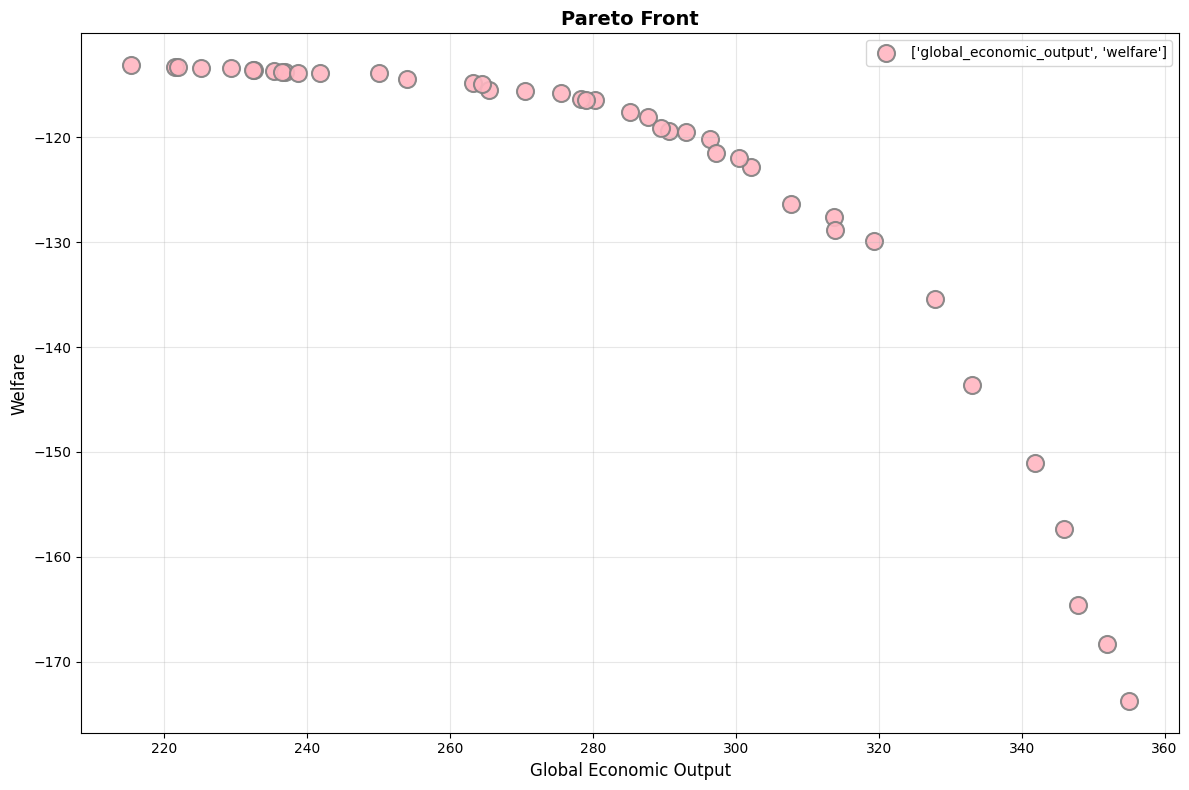

In [112]:
# Interactive plot with hover (Plotly)
if PLOTLY_AVAILABLE:
    fig_pareto_interactive = plot_pareto_front_interactive(df)
    fig_pareto_interactive.show()
else:
    print("Plotly not available, showing static plot")

# Static plot (matplotlib) - for saving
fig_pareto = plot_pareto_front(df, show_weights=False)
if SAVE_FIGURES:
    fig_pareto.savefig(OUTPUT_DIR / "pareto_front.png", dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

## 6. Hypervolume Over Time

In [113]:
def compute_hypervolume(points: np.ndarray, ref_point: List[float]) -> float:
    """Compute hypervolume for points (maximization). DEAP assumes minimization, so we negate.

    Assumes points are already normalized or scaled as desired.
    """
    if not HV_AVAILABLE or len(points) == 0:
        return 0.0
    
    ref = np.array(ref_point)
    valid_mask = np.all(points > ref, axis=1)
    if not valid_mask.any():
        return 0.0
    
    # Negate for DEAP (minimization)
    return hv.hypervolume((-points[valid_mask]).tolist(), (-ref).tolist())


def fetch_training_history_from_wandb(runs_df, entity: str, project: str) -> Dict[str, pd.DataFrame]:
    """Fetch training history for all runs from WandB API.
    Returns histories dict with algorithm info embedded in each DataFrame."""
    api = wandb.Api()
    
    histories = {}
    i = 0 
    for run_id, algorithm in zip(runs_df["run_id"], runs_df["algorithm"]):
        if i % 50 == 0:
            print(f"Fetching history for run {i}/{len(runs_df)}")
        i += 1
        try:
            online_data = api.run(f"{entity}/{project}/{run_id}")
        except Exception as e:
            print(f"Failed to fetch run {run_id}")
            continue
        #print(f"Fetching run {run_id}")
        if "summary" in online_data.name.lower():
            continue
        
        zero_df = online_data.history(keys=["0"])
        one_df = online_data.history(keys=["1"])
        steps_df = online_data.history(keys=["total_num_steps"])
        history_df = pd.DataFrame({
            "run_id": run_id,
            "algorithm": algorithm,
            "total_num_steps": steps_df["total_num_steps"],
            "0": zero_df["0"],
            "1": one_df["1"]
        })
        
        histories[run_id] = history_df
    return histories


def compute_hypervolume_over_time(histories: Dict[str, pd.DataFrame],
                                   ref_point: List[float], num_bins: int = 100) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
    """Compute hypervolume at each time bin for each algorithm (normalized per objective).
    
    For each algorithm:
    1. Collect all points (obj_0, obj_1) across its runs
    2. Compute per-objective min/max over ALL its points
    3. At each timestep, normalize collected points to [0, 1] per objective
    4. Compute hypervolume for the normalized points
    
    Returns dict: algo -> (steps, hv_values)
    """
    if not HV_AVAILABLE:
        return {}
    
    # Group histories by algorithm (extracted from DataFrame)
    algo_histories: Dict[str, List[pd.DataFrame]] = {}
    for run_id, hist in histories.items():
        algo = hist["algorithm"].iloc[0] if len(hist) > 0 else "UNKNOWN"
        algo_histories.setdefault(algo, []).append(hist)
    
    results = {}
    for algo, hist_list in algo_histories.items():
        # Collect ALL data points: (steps, obj_0, obj_1) from all runs
        all_data = []
        for hist in hist_list:
            valid_rows = hist.dropna(subset=["total_num_steps", "0", "1"])
            for _, row in valid_rows.iterrows():
                all_data.append((row["total_num_steps"], row["0"], row["1"]))
        
        if not all_data:
            continue
        
        # Convert to array for global per-objective min/max
        all_array = np.array([[d[1], d[2]] for d in all_data])
        obj_mins = all_array.min(axis=0)
        obj_maxs = all_array.max(axis=0)
        obj_ranges = obj_maxs - obj_mins
        # Avoid division by zero for constant objectives
        obj_ranges[obj_ranges == 0.0] = 1.0
        
        all_data.sort(key=lambda x: x[0])
        max_steps = int(all_data[-1][0])
        
        # Compute HV at each timestep using normalized points
        hv_values, step_centers = [], []
        
        for i in range(num_bins):
            threshold = int(max_steps * (i + 1) / num_bins)
            # Collect ALL points up to this threshold
            points_raw = np.array([[d[1], d[2]] for d in all_data if d[0] <= threshold])
            
            if len(points_raw) > 0:
                # Normalize per objective to [0, 1]
                points_norm = (points_raw - obj_mins) / obj_ranges
                try:
                    hv_val = compute_hypervolume(points_norm, ref_point)
                    hv_values.append(hv_val)
                    step_centers.append(threshold)
                except Exception:
                    pass
        
        if hv_values:
            results[algo] = (np.array(step_centers), np.array(hv_values))
    
    return results


def plot_hypervolume_over_time(hv_over_time: Dict[str, Tuple[np.ndarray, np.ndarray]]) -> plt.Figure:
    """Plot hypervolume learning curves (already aggregated per algorithm)."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algo, data in hv_over_time.items():
        steps, hv = data
        color = COLORS.get(algo, "#333")
        
        # Plot line
        if ALGORITHM_COMPARISON:
            ax.plot(steps, hv, color=color, linewidth=2, label=algo)
        else:
            ax.plot(steps, hv, color=color, linewidth=2, label=f"{OBJECTIVE_NAMES}")
        
        # Annotate final value
        ax.annotate(f'{hv[-1]:.0f}', 
                   xy=(steps[-1], hv[-1]), xytext=(5, 0),
                   textcoords='offset points', fontsize=9, color=color)
    
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Hypervolume (normalized objectives)")
    ax.set_title(f"Hypervolume Over Training (ref={HYPERVOLUME_REF_POINT})", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

In [114]:
if WANDB_AVAILABLE and USE_WANDB_API and HV_AVAILABLE:
    print("Fetching from WandB API...")
    histories = fetch_training_history_from_wandb(df, WANDB_ENTITY, WANDB_PROJECT)
    
    # Extract algorithms from histories
    algos_found = {hist["algorithm"].iloc[0] for hist in histories.values() if len(hist) > 0}
    print(f"\nLoaded {len(histories)} runs, algorithms: {algos_found}")

Fetching from WandB API...
Fetching history for run 0/100
Fetching history for run 50/100

Loaded 100 runs, algorithms: {'UNKNOWN'}


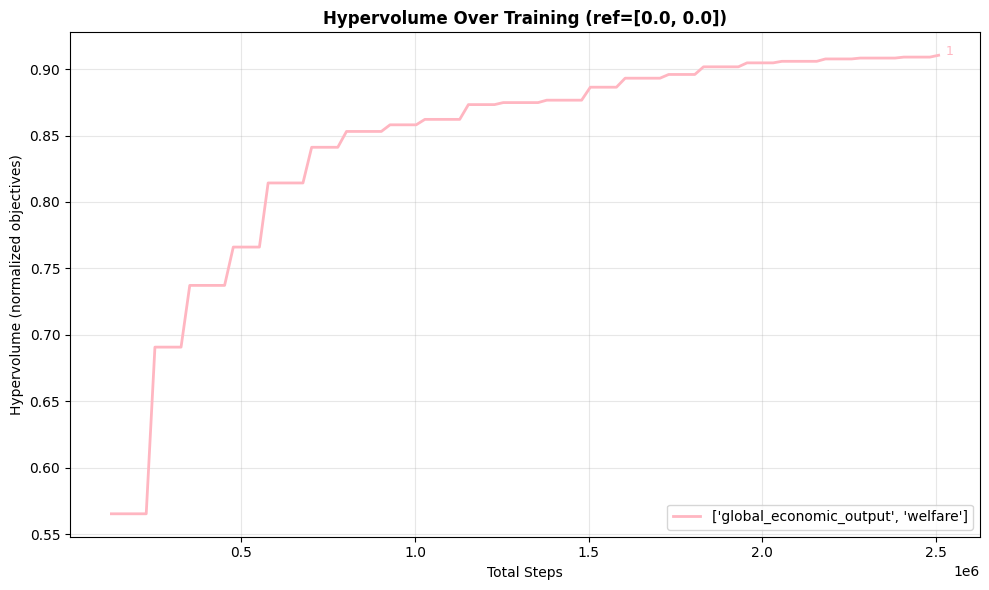

In [115]:
hv_over_time = compute_hypervolume_over_time(histories, HYPERVOLUME_REF_POINT)

if hv_over_time:
    fig_hv_time = plot_hypervolume_over_time(hv_over_time)
    if SAVE_FIGURES:
        fig_hv_time.savefig(OUTPUT_DIR / "hypervolume_over_time.png", dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
else:
    print("No data for HV over time")


## 7. Expected Utility Over Time

In [116]:
def compute_expected_utility_over_time(histories: Dict[str, pd.DataFrame],
                                       runs_df: pd.DataFrame,
                                       num_bins: int = 100) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
    """Compute expected utility over time for each algorithm.

    Expected utility is computed as a weighted sum of the two objectives:
        EU = weight_0 * obj_0 + weight_1 * obj_1
    where weights are taken from the aggregated runs DataFrame.

    For each algorithm:
      1. Collect all (steps, EU) pairs across its runs
      2. For each time bin, consider all points with steps <= threshold
      3. Compute the mean EU across those points
    Returns: algo -> (steps, mean_eu).
    """
    results: Dict[str, Tuple[np.ndarray, np.ndarray]] = {}
    
    # Group histories by algorithm
    algo_histories: Dict[str, List[pd.DataFrame]] = {}
    for run_id, hist in histories.items():
        if len(hist) == 0:
            continue
        algo = hist["algorithm"].iloc[0] if "algorithm" in hist.columns else "UNKNOWN"
        algo_histories.setdefault(algo, []).append(hist)
    
    for algo, hist_list in algo_histories.items():
        all_data: List[Tuple[float, float]] = []  # (steps, expected_utility)
        all_array: List[Tuple[float, float]] = []  # For global min/max per objective
        
        for hist in hist_list:
            valid_rows = hist.dropna(subset=["total_num_steps", "0", "1"])
            for _, row in valid_rows.iterrows():
                all_array.append((row["0"], row["1"]))
        
        all_array = np.array(all_array)
        obj_mins = all_array.min(axis=0)
        obj_maxs = all_array.max(axis=0)
        obj_ranges = obj_maxs - obj_mins
        # Avoid division by zero for constant objectives
        obj_ranges[obj_ranges == 0.0] = 1.0
        
        for hist in hist_list:
            if len(hist) == 0:
                continue
            # Get run_id from history and look up weights in runs_df
            run_id = hist["run_id"].iloc[0] if "run_id" in hist.columns else None
            if run_id is None:
                continue
            match = runs_df[runs_df["run_id"] == run_id]
            if match.empty:
                continue
            w0 = float(match["weight_0"].iloc[0])
            w1 = float(match["weight_1"].iloc[0])

            valid_rows = hist.dropna(subset=["total_num_steps", "0", "1"])
            for _, row in valid_rows.iterrows():
                eu = w0 * (row["0"] - obj_mins[0]) / obj_ranges[0] + w1 * (row["1"] - obj_mins[1]) / obj_ranges[1] 
                all_data.append((row["total_num_steps"], eu))
        
        if not all_data:
            continue
        
        all_data.sort(key=lambda x: x[0])
        max_steps = int(all_data[-1][0])
        
        eu_values, step_centers = [], []
        
        for i in range(num_bins):
            threshold = int(max_steps * (i + 1) / num_bins)
            vals = [d[1] for d in all_data if d[0] <= threshold]
            if vals:
                eu_values.append(float(np.mean(vals)))
                step_centers.append(threshold)
        
        if eu_values:
            results[algo] = (np.array(step_centers), np.array(eu_values))
    
    return results


def plot_expected_utility_over_time(eu_over_time: Dict[str, Tuple[np.ndarray, np.ndarray]]) -> plt.Figure:
    """Plot expected utility learning curves for each algorithm."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for algo, data in eu_over_time.items():
        steps, eu = data
        color = COLORS.get(algo, "#333")
        
        if ALGORITHM_COMPARISON:
            ax.plot(steps, eu, color=color, linewidth=2, label=algo)
        else:
            ax.plot(steps, eu, color=color, linewidth=2, label=f"{OBJECTIVE_NAMES}")
        
        # Annotate final value
        ax.annotate(f"{eu[-1]:.2f}",
                   xy=(steps[-1], eu[-1]), xytext=(5, 0),
                   textcoords='offset points', fontsize=9, color=color)
    
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Expected Utility (w0 * obj0 + w1 * obj1)")
    ax.set_title("Expected Utility Over Training", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


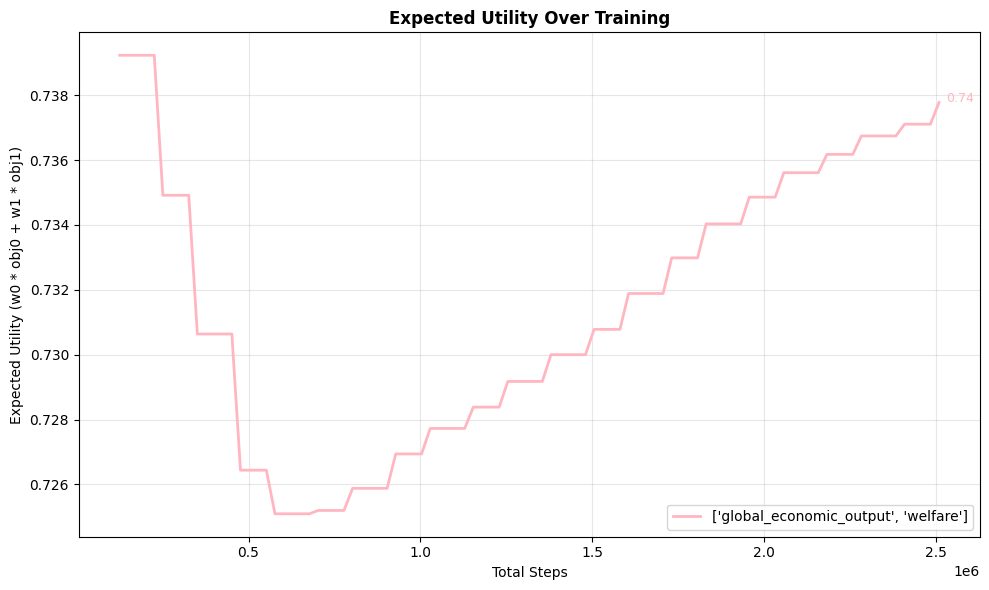

In [117]:
eu_over_time = compute_expected_utility_over_time(histories, df)
    
if eu_over_time:
    fig_eu_time = plot_expected_utility_over_time(eu_over_time)
    if SAVE_FIGURES:
        fig_eu_time.savefig(OUTPUT_DIR / "expected_utility_over_time.png", dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()
else:
    print("No data for expected utility over time")

## 8. Summary

In [118]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

for algo in df["algorithm"].unique():
    algo_df = df[df["algorithm"] == algo]
    points = algo_df[["return_obj_0", "return_obj_1"]].values
    pareto_count = is_pareto_efficient(points).sum()
    
    print(f"\n{algo} ({len(algo_df)} runs, {pareto_count} Pareto):")
    for i, name in enumerate(OBJECTIVE_NAMES):
        col = f"return_obj_{i}"
        print(f"  {name}: {algo_df[col].mean():.2f} ± {algo_df[col].std():.2f} [{algo_df[col].min():.2f}, {algo_df[col].max():.2f}]")

print("\n" + "=" * 60)
df.sort_values(["algorithm", "weight_idx"])

SUMMARY STATISTICS

UNKNOWN (100 runs, 42 Pareto):
  global_economic_output: 255.88 ± 45.83 [201.31, 355.06]
  welfare: -120.24 ± 13.76 [-176.53, -113.12]



,run_id,algorithm,weight_0,weight_1,weight_idx,reward_0,reward_1,return_obj_0,return_obj_1,timestamp,total_steps
110,qzzd8jai,UNKNOWN,0.000000,1.000000,0,global_economic_output,welfare,201.305462,-113.464608,20260326_040336,2508000
111,57ui8wor,UNKNOWN,0.050067,0.949933,0,global_economic_output,welfare,203.101546,-113.428405,20260326_041300,2508000
112,yu7tp49v,UNKNOWN,0.150527,0.849473,0,global_economic_output,welfare,215.433912,-113.118069,20260326_041300,2508000
113,irp6bo7k,UNKNOWN,0.100278,0.899722,0,global_economic_output,welfare,206.091518,-113.305557,20260326_041301,2508000
114,axt5r225,UNKNOWN,0.352273,0.647727,0,global_economic_output,welfare,220.482780,-113.301304,20260326_042435,2508000
...,...,...,...,...,...,...,...,...,...,...,...
215,yp1w9ugj,UNKNOWN,0.898365,0.101635,4,global_economic_output,welfare,326.571376,-136.755321,20260326_193536,2508000
217,qiz2yzzo,UNKNOWN,1.000000,0.000000,4,global_economic_output,welfare,352.554778,-176.528455,20260326_194045,2508000
218,iv1qym33,UNKNOWN,0.796830,0.203170,4,global_economic_output,welfare,300.503626,-121.962573,20260326_194429,2508000
219,i3e8qr14,UNKNOWN,0.746166,0.253834,4,global_economic_output,welfare,292.993457,-119.475905,20260326_194853,2508000
